# 02 — Data Preprocessing & Feature Engineering
## Used Car Price Prediction

**Purpose:** Apply all filters and transformations identified in EDA, engineer new features, encode categoricals, and produce a clean train/validation/test split ready for modeling.

> **Status:** To be completed after EDA sign-off.

**Picks up from:** `df_clean_preview` — the price/year/odometer-filtered frame produced at the end of EDA, with `vehicle_age` and `log_odometer` already present.

### What was already done in EDA (not repeated here)
- Raw CSV loaded, 17 columns selected
- Price filtered to `[$500, $150K]`, year to `[1980, 2025]`, odometer to `[0, 400K]` → **372K rows**
- `vehicle_age` and `log_odometer` derived
- Missing-value rates, distributions, and correlations fully explored

### What this notebook adds
1. [Restore from EDA](#1-restore)
2. [Drop Columns & Impute Missing Values](#2-impute)
3. [Feature Engineering — remaining features](#3-features)
4. [Categorical Encoding](#4-encoding)
5. [Train / Validation / Test Split](#5-split)
6. [Leakage-safe Group Feature: `state_median_price`](#6-group-feature)
7. [Save Processed Data](#7-save)

---
## 1. Restore from EDA <a id='1-restore'></a>

We retrieve the filtered dataframe stored by `01_EDA.ipynb` using `%store -r`.  
No CSV re-read, no repeated filtering.

In [15]:
import warnings
warnings.filterwarnings('ignore')

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append('../src')
from data_processing import (
    impute_categoricals, CONDITION_ORDER, CYLINDERS_MAP, CAT_COLS
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
SEED = 42

print('Libraries loaded.')

Libraries loaded.


In [16]:
# Retrieve variables stored at the end of 01_EDA.ipynb
%store -r df_clean_preview
%store -r CURRENT_YEAR

# Work on a copy so the EDA frame stays intact if needed
df = df_clean_preview.copy()

print(f'Restored from EDA: {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f"Columns already present from EDA: {[c for c in ['vehicle_age', 'log_odometer'] if c in df.columns]}")

Restored from EDA: 372,234 rows  x  20 columns
Columns already present from EDA: ['vehicle_age', 'log_odometer']


---
## 2. Drop Columns & Impute Missing Values <a id='2-impute'></a>

EDA established the following strategy (see Notebook 01, Section 9):

| Column | Action | Reason |
|---|---|---|
| `size` | **Drop** | 72% missing — too sparse to be reliable |
| `model` | **Drop** | 50K+ unique free-text values; not encodable cleanly |
| `condition` | Impute → `'unknown'` | 38% missing; ordinal-encode including unknown |
| `cylinders` | Impute → `'unknown'` / int `0` | 33% missing |
| `drive`, `paint_color`, `type` | Impute → `'unknown'` | 20–30% missing |
| `manufacturer`, `title_status`, `fuel`, `transmission` | Impute → `'unknown'` | <5% missing |
| `odometer` | Impute → **column median** | <1% missing |
| `lat`, `long` | Keep NaN | Not in model matrix; used for optional geo features only |

In [17]:
drop_cols = [c for c in ['size', 'model'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print("Dropped: 'size'  (72.0% missing)")
print("Dropped: 'model' (free-text, not encodable)")

Dropped: 'size'  (72.0% missing)
Dropped: 'model' (free-text, not encodable)


In [18]:
df = impute_categoricals(df, fill_value='unknown')

remaining = df.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print('Remaining NaNs after imputation:')
print(remaining.to_string())
print('\nlat/long NaNs are intentional — excluded from geo features only.')

Remaining NaNs after imputation:
lat     3371
long    3371

lat/long NaNs are intentional — excluded from geo features only.


---
## 3. Feature Engineering — remaining features <a id='3-features'></a>

`vehicle_age` and `log_odometer` already came from EDA. Here we add the three remaining engineered features:

| Feature | Source | Note |
|---|---|---|
| `log_price` | `log1p(price)` | **Model target** — compresses right skew, reduces heteroscedasticity |
| `cylinders_int` | string → int via `CYLINDERS_MAP` | `"4 cylinders"` → `4`; `"other"` / `"unknown"` → `0` |
| `condition_ord` | ordinal map | `salvage=0` … `new=5`; `unknown=−1` |

In [19]:
# Target variable
df['log_price'] = np.log1p(df['price'])

# Cylinders string → integer
df['cylinders_int'] = df['cylinders'].map(CYLINDERS_MAP).fillna(0).astype(int)

# Condition → ordinal (unknown = -1 so it doesn't interfere with valid ordering)
cond_map = {v: i for i, v in enumerate(CONDITION_ORDER)}
cond_map['unknown'] = -1
df['condition_ord'] = df['condition'].map(cond_map).fillna(-1).astype(int)

print(f"log_price     — min: {df['log_price'].min():.2f}   max: {df['log_price'].max():.2f}  mean: {df['log_price'].mean():>6.2f}")
print('\ncylinders_int — value counts:')
print(df['cylinders_int'].value_counts().sort_index(ascending=False).to_string())
print('\ncondition_ord — value counts:')
print(df['condition_ord'].value_counts().sort_index(ascending=False).to_string())

log_price     — min: 6.22   max: 11.92  mean:   9.53

cylinders_int — value counts:
cylinders_int
12       172
10      1131
8      61212
6      84938
5       1632
4      68941
3        575
0     153633

condition_ord — value counts:
condition_ord
 5       961
 4     19201
 3     89159
 2    115659
 1      5818
 0       485
-1    140951


---
## 4. Categorical Encoding <a id='4-encoding'></a>

| Strategy | Columns | Rationale |
|---|---|---|
| **One-hot** | `fuel`, `transmission`, `drive`, `title_status`, `type` | Low cardinality (≤10 unique values); no ordinal relationship |
| **Frequency** | `manufacturer`, `paint_color`, `state` | Medium/high cardinality — avoids dimensionality explosion |

In [20]:
# Lump rare manufacturers before encoding
freq_mfr = df['manufacturer'].value_counts(normalize=True)
rare = freq_mfr[freq_mfr < 0.005].index.tolist()
print("Rare manufacturers (share < 0.5%) collapsed to 'other':")
print(sorted(rare))

n_before = df['manufacturer'].nunique()
df['manufacturer'] = df['manufacturer'].apply(lambda x: 'other' if x in rare else x)
print(f"Unique manufacturers: {n_before} → {df['manufacturer'].nunique()}")

Rare manufacturers (share < 0.5%) collapsed to 'other':
['alfa-romeo', 'aston-martin', 'datsun', 'ferrari', 'fiat', 'harley-davidson', 'jaguar', 'land rover', 'mercury', 'morgan', 'porsche', 'saturn', 'tesla']
Unique manufacturers: 43 → 31


In [21]:
OHE_COLS = ['fuel', 'transmission', 'drive', 'title_status', 'type']

df = pd.get_dummies(df, columns=OHE_COLS, prefix=OHE_COLS, drop_first=False, dtype=int)

ohe_new = [c for c in df.columns if any(c.startswith(f'{col}_') for col in OHE_COLS)]
print(f'Shape after OHE: {df.shape}')
print(f'OHE dummy columns created: {len(ohe_new)}')

Shape after OHE: (372234, 50)
OHE dummy columns created: 35


In [22]:
# Frequency encode — computed on full dataset here (acceptable for population frequencies;
# state_median_price, the target-statistic feature, is computed on train only in Section 6)
FREQ_COLS = ['manufacturer', 'paint_color', 'state']

for col in FREQ_COLS:
    freq_map = df[col].value_counts(normalize=True)
    df[f'{col}_freq'] = df[col].map(freq_map)

print(f'Frequency encoding applied to: {FREQ_COLS}')

Frequency encoding applied to: ['manufacturer', 'paint_color', 'state']


---
## 5. Train / Validation / Test Split <a id='5-split'></a>

**60 / 20 / 20** stratified on price decile buckets to ensure each split covers the full price range proportionally.

In [23]:
df['_price_decile'] = pd.qcut(df['log_price'], q=10, labels=False)

df_train, df_temp = train_test_split(
    df, test_size=0.40, random_state=SEED, stratify=df['_price_decile']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['_price_decile']
)

for split in [df_train, df_val, df_test]:
    split.drop(columns=['_price_decile'], inplace=True)
df.drop(columns=['_price_decile'], inplace=True)

print('Split sizes:')
for name, split in [('Train', df_train), ('Validation', df_val), ('Test', df_test)]:
    print(f'  {name:<12}: {len(split):>7,}  ({len(split)/len(df):.1%})')

Split sizes:
  Train       : 223,340  (60.0%)
  Validation  :  74,447  (20.0%)
  Test        :  74,447  (20.0%)


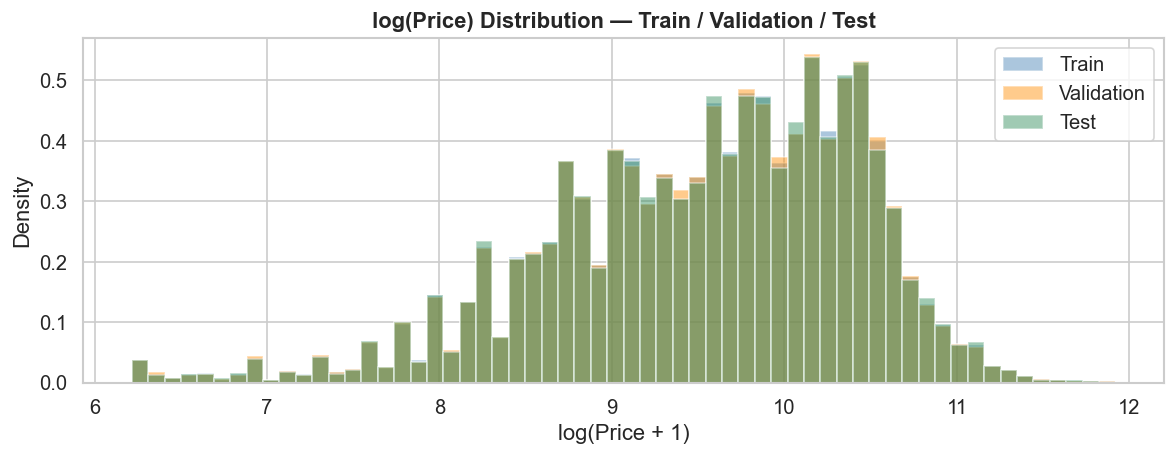

In [24]:
# Sanity check: log_price densities should be nearly identical across splits
fig, ax = plt.subplots(figsize=(10, 4))
for name, split, color in [
    ('Train',      df_train, 'steelblue'),
    ('Validation', df_val,   'darkorange'),
    ('Test',       df_test,  'seagreen'),
]:
    ax.hist(split['log_price'], bins=60, alpha=0.45, label=name, color=color, density=True)

ax.set_title('log(Price) Distribution — Train / Validation / Test', fontweight='bold')
ax.set_xlabel('log(Price + 1)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/02_split_distributions.png', bbox_inches='tight')
plt.show()

---
## 6. Leakage-safe Group Feature: `state_median_price` <a id='6-group-feature'></a>

EDA showed state-level median price has a strong correlation with `log_price` (r ≈ 0.53).  
This is a **target-statistic feature** and must be computed on the **training set only** — computing it on the full dataset before splitting would leak target information into validation and test.

In [25]:
# Compute exclusively on training data
state_median = (
    df_train.groupby('state')['price']
    .median()
    .rename('state_median_price')
)
global_median = df_train['price'].median()

print('state_median_price — top 5 states:')
print(state_median.sort_values(ascending=False).head().to_string())
print(f'\nGlobal fallback median (unseen states): ${global_median:,.0f}')

# Merge into all splits via map (val/test use train-derived values only)
for split in [df_train, df_val, df_test]:
    split['state_median_price'] = split['state'].map(state_median).fillna(global_median)

print("Applied to: train ✓  val ✓  test ✓")

state_median_price — top 5 states:
state
wv    25990.0
ak    22988.0
mt    22900.0
ut    21895.0
wa    21799.0

Global fallback median (unseen states): $15,935
Applied to: train ✓  val ✓  test ✓


---
## 7. Save Processed Data <a id='7-save'></a>

In [26]:
TARGET = 'log_price'

# Exclude raw/source columns superseded by their engineered counterparts
EXCLUDE = ['price', 'log_price', 'year', 'odometer',
           'condition', 'cylinders', 'manufacturer', 'paint_color', 'state']

FEATURE_COLS = [c for c in df_train.columns if c not in EXCLUDE]

print(f'Feature matrix: {len(FEATURE_COLS)} columns\n')
print(FEATURE_COLS)

Feature matrix: 45 columns

['lat', 'long', 'vehicle_age', 'log_odometer', 'cylinders_int', 'condition_ord', 'fuel_diesel', 'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other', 'fuel_unknown', 'transmission_automatic', 'transmission_manual', 'transmission_other', 'transmission_unknown', 'drive_4wd', 'drive_fwd', 'drive_rwd', 'drive_unknown', 'title_status_clean', 'title_status_lien', 'title_status_missing', 'title_status_parts only', 'title_status_rebuilt', 'title_status_salvage', 'title_status_unknown', 'type_SUV', 'type_bus', 'type_convertible', 'type_coupe', 'type_hatchback', 'type_mini-van', 'type_offroad', 'type_other', 'type_pickup', 'type_sedan', 'type_truck', 'type_unknown', 'type_van', 'type_wagon', 'manufacturer_freq', 'paint_color_freq', 'state_freq', 'state_median_price']


In [27]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_train.to_parquet('../data/processed/train.parquet', index=False)
df_val.to_parquet('../data/processed/validation.parquet', index=False)
df_test.to_parquet('../data/processed/test.parquet', index=False)

with open('../data/processed/feature_cols.txt', 'w') as f:
    f.write('\n'.join(FEATURE_COLS))

print('Saving to ../data/processed/ ...')
print(f'  train.parquet       → {len(df_train):>7,} rows')
print(f'  validation.parquet  → {len(df_val):>7,} rows')
print(f'  test.parquet        → {len(df_test):>7,} rows')
print(f'  feature_cols.txt    →  {len(FEATURE_COLS):>2} features')
print('Done.')

Saving to ../data/processed/ ...
  train.parquet       → 223,340 rows
  validation.parquet  →  74,447 rows
  test.parquet        →  74,447 rows
  feature_cols.txt    →  45 features
Done.


In [28]:
# Pass processed splits forward to 03_Modeling.ipynb
%store df_train
%store df_val
%store df_test
%store FEATURE_COLS
%store TARGET

print('Stored: df_train, df_val, df_test, FEATURE_COLS, TARGET')
print('03_Modeling.ipynb can retrieve these with  %store -r')

Stored 'df_train' (DataFrame)
Stored 'df_val' (DataFrame)
Stored 'df_test' (DataFrame)
Stored 'FEATURE_COLS' (list)
Stored 'TARGET' (str)
Stored: df_train, df_val, df_test, FEATURE_COLS, TARGET
03_Modeling.ipynb can retrieve these with  %store -r


---
*Preprocessing complete. Proceed to `03_Modeling.ipynb`.*